Section 1 — Import Libraries,load datset

In [64]:
import pandas as pd

df = pd.read_csv("train.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Explore dataset

In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Clean Age, Check Missing Values

In [66]:
df["Age"] = df["Age"].fillna(df["Age"].mean())

In [67]:
df["Age"].isnull().sum()

np.int64(0)

Survival by Gender

In [68]:
df.groupby("Sex")["Survived"].sum()

,Survived
Sex,
female,233
male,109


Create Bar Chart: Survival by Gender

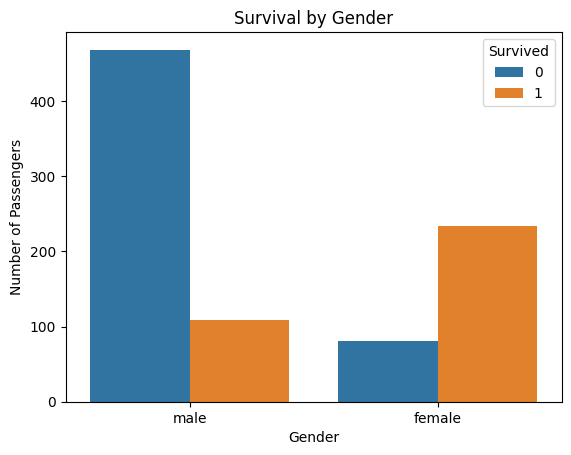

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=df, x="Sex", hue="Survived")

plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")
plt.show()

Survival by Class

In [70]:
df.groupby("Pclass")["Survived"].sum()

,Survived
Pclass,
1,136
2,87
3,119


In [71]:
df.groupby("Pclass")["Survived"].mean() * 100

,Survived
Pclass,
1,62.962963
2,47.282609
3,24.236253


Create Bar Chart: Survival by class





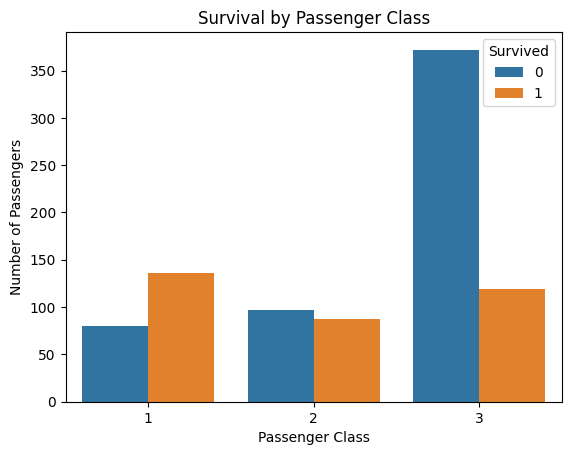

In [72]:
sns.countplot(data=df, x="Pclass", hue="Survived")

plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.show()

Create Age Groups

In [73]:
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0, 12, 18, 35, 60, 100],
    labels=["Child", "Teenager", "Young Adult", "Adult", "Senior"]
)

In [74]:
df[["Age", "AgeGroup"]].head(10)

,Age,AgeGroup
0,22.000000,Young Adult
1,38.000000,Adult
2,26.000000,Young Adult
3,35.000000,Young Adult
4,35.000000,Young Adult
5,29.699118,Young Adult
6,54.000000,Adult
7,2.000000,Child
8,27.000000,Young Adult
9,14.000000,Teenager


Survival by Age Group

In [75]:
df.groupby("AgeGroup", observed=True)["Survived"].mean() * 100

,Survived
AgeGroup,
Child,57.971014
Teenager,42.857143
Young Adult,35.327103
Adult,40.000000
Senior,22.727273




Survival by Age Group



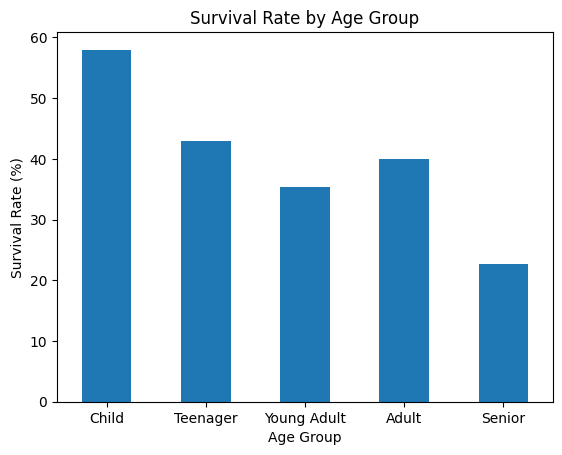

In [76]:
age_survival = df.groupby("AgeGroup", observed=True)["Survived"].mean() * 100

age_survival.plot(kind="bar")

plt.title("Survival Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Survival Rate (%)")
plt.xticks(rotation=0)
plt.show()

Age Histogram

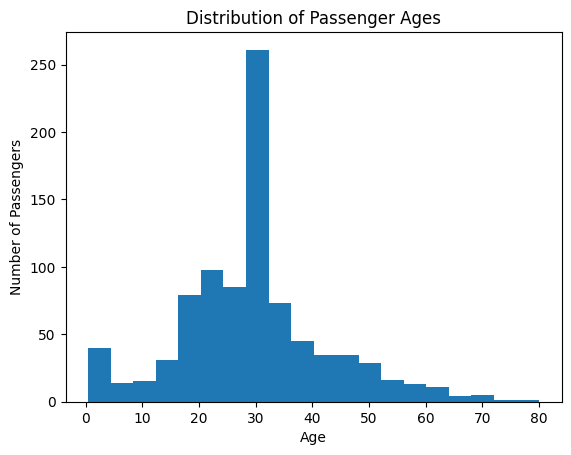

In [77]:
plt.hist(df["Age"], bins=20)

plt.title("Distribution of Passenger Ages")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.show()

In [78]:
gender_survival = df.groupby("Sex")["Survived"].mean() * 100
gender_survival

,Survived
Sex,
female,74.203822
male,18.890815


In [79]:
class_survival = df.groupby("Pclass")["Survived"].mean() * 100
class_survival

,Survived
Pclass,
1,62.962963
2,47.282609
3,24.236253


In [80]:
age_survival

,Survived
AgeGroup,
Child,57.971014
Teenager,42.857143
Young Adult,35.327103
Adult,40.000000
Senior,22.727273


In [81]:
print("Survival Rate by Gender:")
print(gender_survival)

print("\nSurvival Rate by Class:")
print(class_survival)

print("\nSurvival Rate by Age Group:")
print(age_survival)

Survival Rate by Gender:
Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64

Survival Rate by Class:
Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64

Survival Rate by Age Group:
AgeGroup
Child          57.971014
Teenager       42.857143
Young Adult    35.327103
Adult          40.000000
Senior         22.727273
Name: Survived, dtype: float64


## Conclusion



The Titanic dataset was cleaned and analyzed using Python, Pandas, Matplotlib, and Seaborn.

* Female passengers had a higher survival rate (**74.20%**) compared with male passengers (**18.89%**).
* Passenger class was associated with different survival rates. The survival rates were **62.96% for 1st class, 47.28% for 2nd class, and 24.24% for 3rd class**.
* Survival rates also varied across age groups. Children had a survival rate of **57.97%**, while seniors had a survival rate of **22.73%**.
* Missing Age values were handled by replacing them with the mean age.
* Visualizations helped identify survival patterns by gender, passenger class, and age.
